<a href="https://colab.research.google.com/github/khiba-k/Python_ML_Linear_Regression/blob/main/Call_Hours_vs_Revenue_Generated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [4]:
data = {
    'call_hours': [5, None, 15, 20, 22, 25, None, 35, 40, 42, 45, 50, 55, None, 65],
    'revenue_thousands': [18, 25, 40, 52, 58, 65, 75, 88, 100, 106, 112, 125, 138, 148, 162]
}

df = pd.DataFrame(data)

In [10]:
# Separate Data into independednt and dependent variables
call_hrs_arr = df.iloc[:, :-1].values
rev_arr = df.iloc[:, -1].values

In [14]:
# Impute Missing independent variables
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
call_hrs_imp = imputer.fit_transform(call_hrs_arr)

In [16]:
# Split data into Training & Testing Sets
call_hrs_train, call_hrs_test, rev_train, rev_test = train_test_split(call_hrs_imp, rev_arr, test_size=0.2, random_state=42)

In [19]:
# Scaled Down Independent Variables
scaler = StandardScaler()
call_hrs_train_scaled = scaler.fit_transform(call_hrs_train)
call_hrs_test_scaled = scaler.transform(call_hrs_test)

In [22]:
# Fit Model
regressor = LinearRegression()
regressor.fit(call_hrs_train_scaled, rev_train)

LinearRegression()

In [24]:
# Predict Training & Test Sets
predicted_rev_training = regressor.predict(call_hrs_train_scaled)
predicted_rev_test = regressor.predict(call_hrs_test_scaled)

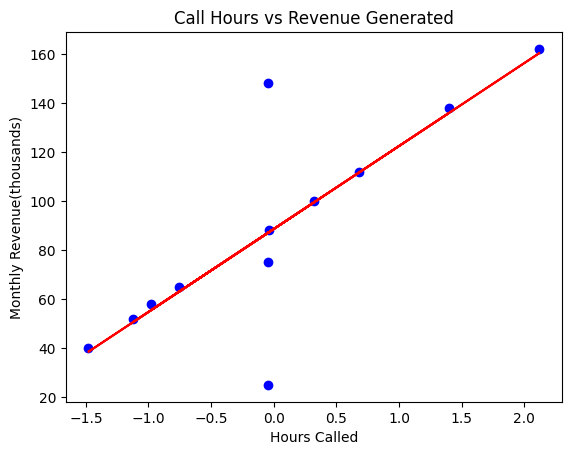

In [27]:
# Plot Training Data & Regression Line
plt.scatter(call_hrs_train_scaled, rev_train, color='blue')
plt.plot(call_hrs_train_scaled, predicted_rev_training, color='red')
plt.title('Call Hours vs Revenue Generated')
plt.xlabel('Hours Called')
plt.ylabel('Monthly Revenue(thousands)')
plt.show()

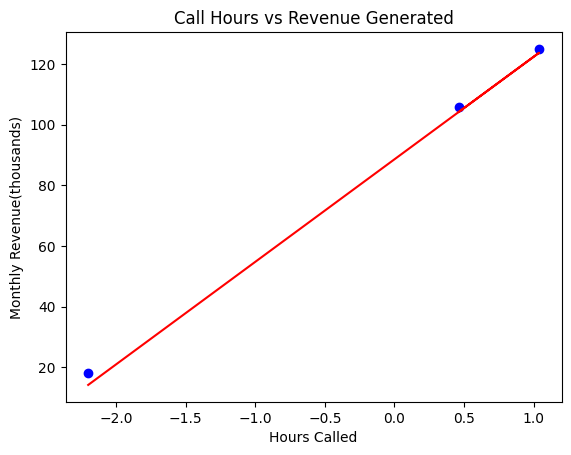

In [28]:
# Plot Test Data & Regression Line
plt.scatter(call_hrs_test_scaled, rev_test, color='blue')
plt.plot(call_hrs_test_scaled, predicted_rev_test, color='red')
plt.title('Call Hours vs Revenue Generated')
plt.xlabel('Hours Called')
plt.ylabel('Monthly Revenue(thousands)')
plt.show()